In [18]:
import pandas as pd
URL = "https://raw.githubusercontent.com/ShuklaPrashant21/Used-Car-Price-Prediction/refs/heads/master/car%20data.csv"
df = pd.read_csv(URL)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [19]:
#Preprocesameinto
#limpia de datos
#y = ["Selling_Price"]
#X = df.drop(["Car_Name","Seller_Type","Owner"])
print(df.info())
#analizamos si existen datos nulos y en caso de que hubiese 30% de datos nulos o mas, se elimina la columna
#en caso contrario se mantiene
nulo = df.isnull().sum()
print(nulo)
duplicados = df.duplicated().sum()
print(duplicados)
#eliminar duplicados
df = df.drop_duplicates()


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB
None
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
2


In [20]:
#Dividir datos en X e y
y = df["Selling_Price"]
X = df.drop(["Car_Name","Seller_Type","Owner"],axis=1)
#Convertir datos categoricos objeto a datos numericos
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X["Fuel_Type"] = le.fit_transform(X["Fuel_Type"])
X["Transmission"] = le.fit_transform(X["Transmission"])
print(X)
print(y)

     Year  Selling_Price  Present_Price  Kms_Driven  Fuel_Type  Transmission
0    2014           3.35           5.59       27000          2             1
1    2013           4.75           9.54       43000          1             1
2    2017           7.25           9.85        6900          2             1
3    2011           2.85           4.15        5200          2             1
4    2014           4.60           6.87       42450          1             1
..    ...            ...            ...         ...        ...           ...
296  2016           9.50          11.60       33988          1             1
297  2015           4.00           5.90       60000          2             1
298  2009           3.35          11.00       87934          2             1
299  2017          11.50          12.50        9000          1             1
300  2016           5.30           5.90        5464          2             1

[299 rows x 6 columns]
0       3.35
1       4.75
2       7.25
3       2.85


In [21]:
#Escalado de datos
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)
print(X)
#Dividir datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)


[[ 0.13299198 -0.24912732 -0.22809681 -0.25460295  0.49184668  0.38729833]
 [-0.21278716  0.03222894  0.23369991  0.15618145 -1.88012358  0.38729833]
 [ 1.17032939  0.53465083  0.26994218 -0.77065085  0.49184668  0.38729833]
 ...
 [-1.59590371 -0.24912732  0.40438933  1.30981807  0.49184668  0.38729833]
 [ 1.17032939  1.38876804  0.57975517 -0.71673539 -1.88012358  0.38729833]
 [ 0.82455025  0.14276175 -0.19185453 -0.80751874  0.49184668  0.38729833]]


In [22]:
#Modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
modelo = Sequential([
    Dense(6, activation="relu", input_shape=(6,)),
    Dense(4, activation="relu"),
    Dense(1, activation="linear")
])
#Entrenamos el modelo
modelo.compile(optimizer="adam", loss=["mse"], metrics=["mae"])
historial = modelo.fit(X_train, y_train, epochs = 200, batch_size=16,validation_split=0.2)

Epoch 1/200


c:\Users\pumas\OneDrive\Documents\.venv13\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 55.7408 - mae: 4.9755 - val_loss: 30.5173 - val_mae: 4.1046
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 55.3056 - mae: 4.9344 - val_loss: 30.2394 - val_mae: 4.0662
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 54.8769 - mae: 4.8931 - val_loss: 29.9491 - val_mae: 4.0228
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 54.4843 - mae: 4.8486 - val_loss: 29.6362 - val_mae: 3.9757
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 54.0211 - mae: 4.7981 - val_loss: 29.3180 - val_mae: 3.9273
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 53.5695 - mae: 4.7468 - val_loss: 28.9649 - val_mae: 3.8822
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 53.0441 - mae: 4.6944 - val_loss: 28.5868 - val_mae: 3.8396
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 52.4904 - mae: 4.6440 - val_loss: 28.1784 - val_mae: 3.8009
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 

<function matplotlib.pyplot.show(close=None, block=None)>

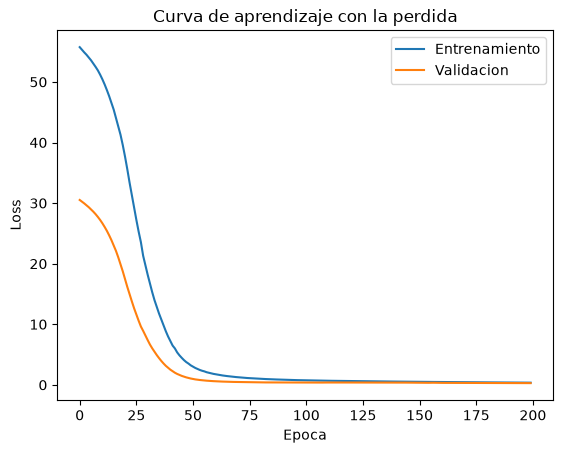

In [23]:
#Graficar los errores
import matplotlib.pyplot as plt
#graficar el aprendizaje de la red
plt.plot(historial.history["loss"],label = "Entrenamiento")
plt.plot(historial.history["val_loss"],label="Validacion")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Curva de aprendizaje con la perdida")
plt.legend()
plt.show

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000022BB19B3CE0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


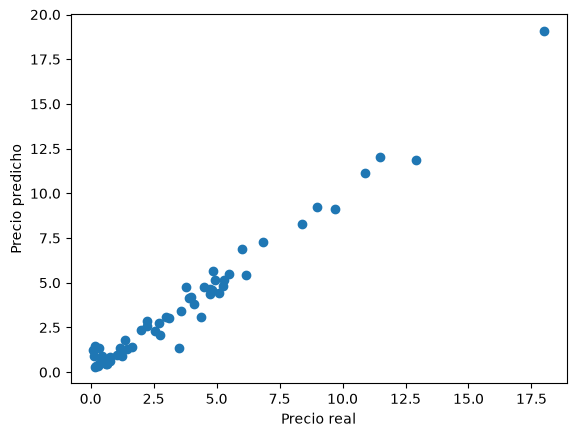

In [24]:
#Tabla de comparacion#Comparar las predicciones vs los datos reales
y_pred = modelo.predict(X_test)
plt.scatter(y_test, y_pred)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.show()

In [25]:
#Comparacion numerica entre el dato real y el dato predicho
#y_test vs y_pred
print("Valore real: ", y_test[:5])
print("Valores predichos: ", y_pred[:5])

Valore real:  239    2.00
141    0.60
225    2.70
197    0.16
277    9.70
Name: Selling_Price, dtype: float64
Valores predichos:  [[2.3311224 ]
 [0.68901294]
 [2.7233067 ]
 [0.30628106]
 [9.124957  ]]
